**Boosting**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/breast-cancer.csv')

In [ ]:
X = df.drop(columns=['id', 'diagnosis'])
y = df['diagnosis']

In [ ]:
#TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=150
)

In [ ]:
#BASE MODEL: DECISION TREE
dt_model = DecisionTreeClassifier(max_depth=3)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
print("\nDecision Tree Accuracy:")
print(accuracy_score(y_test, dt_pred))


Decision Tree Accuracy:
0.9473684210526315


In [ ]:
#ADABOOST
ada_model = AdaBoostClassifier(
estimator=DecisionTreeClassifier(max_depth=3),
n_estimators=200,
learning_rate=0.01,
random_state=150
)
ada_model.fit(X_train, y_train)
ada_pred = ada_model.predict(X_test)
print("\nAdaBoost Accuracy:")
print(accuracy_score(y_test, ada_pred))


AdaBoost Accuracy:
0.9649122807017544


In [ ]:
#GRADIENT BOOSTING
gb_model = GradientBoostingClassifier(
n_estimators=200,
learning_rate=0.01,
max_depth=3,
random_state=100
)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
print("\nGradient Boosting Accuracy:")
print(accuracy_score(y_test, gb_pred))



Gradient Boosting Accuracy:
0.9649122807017544


In [ ]:
#XGBOOST
from sklearn.preprocessing import LabelEncoder

# Encode target labels 'B' and 'M' to numerical (0 and 1)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.01,
    max_depth=3,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=150
)
xgb_model.fit(X_train, y_train_encoded)
xgb_pred_encoded = xgb_model.predict(X_test)

# For printing accuracy, we can compare with the encoded y_test
print("\nXGBoost Accuracy:")
print(accuracy_score(y_test_encoded, xgb_pred_encoded))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:27:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Accuracy:
0.9912280701754386


In [ ]:
#DETAILED REPORT
print("\nClassification Report (XGBoost):")
print(classification_report(y_test_encoded, xgb_pred_encoded))


Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        72
           1       1.00      0.98      0.99        42

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



**Clustering**

In [ ]:
#implementing clustering techniques
# IMPORT LIBRARIES
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler

In [ ]:
#GENERATE SAMPLE DATA
X, y_true = make_blobs(
n_samples=300,
centers=4,
cluster_std=1.0,
random_state=50
)

In [ ]:
#FEATURE SCALING
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
#clustering
kmeans = KMeans(n_clusters=4, random_state=60)
kmeans_labels = kmeans.fit_predict(X_scaled)
hierarchical = AgglomerativeClustering(n_clusters=4)
hierarchical_labels = hierarchical.fit_predict(X_scaled)
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
plt.figure(figsize=(15, 5))

<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

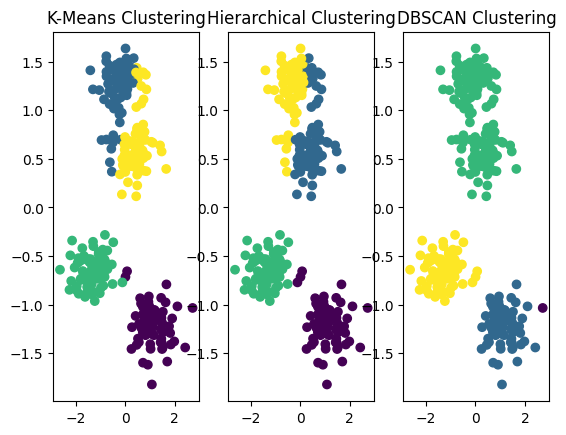

In [ ]:
# KMeans Plot
plt.subplot(1, 3, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels)
plt.title("K-Means Clustering")
# Hierarchical Plot
plt.subplot(1, 3, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=hierarchical_labels)
plt.title("Hierarchical Clustering")
# DBSCAN Plot
plt.subplot(1, 3, 3)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=dbscan_labels)
plt.title("DBSCAN Clustering")
plt.show()

**Divisive hieararchical clustering**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X, y_true = make_blobs(
n_samples=300,
centers=4,
cluster_std=1.0,
random_state=42
)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

def divisive_clustering(X_data, n_clusters):
    # Step 1: Start with one cluster (all data)
    # Store clusters as dictionaries mapping original indices to the cluster key
    # This is crucial for assigning final labels
    clusters_map = {0: {'data': X_data, 'indices': np.arange(len(X_data))}}
    current_cluster_key = 1 # Key for new clusters created during splitting

    # Step 2: Keep splitting until desired number of clusters is reached
    while len(clusters_map) < n_clusters:
        # Select the largest cluster (by number of data points) to split
        # We need to handle the case where a cluster might become too small to split
        largest_cluster_key_to_split = max(clusters_map, key=lambda k: len(clusters_map[k]['data']))

        data_to_split = clusters_map[largest_cluster_key_to_split]['data']
        indices_to_split = clusters_map[largest_cluster_key_to_split]['indices']

        # If a cluster has only one point, it cannot be split further
        if len(data_to_split) < 2:
            break

        # Apply KMeans with 2 clusters to split the selected cluster
        # Using n_init='auto' or explicit number to suppress warning
        kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
        split_labels = kmeans.fit_predict(data_to_split)

        # Remove the old cluster from the map
        del clusters_map[largest_cluster_key_to_split]

        # Create two new clusters based on the split
        # Assign the old cluster key to one part of the split
        clusters_map[largest_cluster_key_to_split] = {
            'data': data_to_split[split_labels == 0],
            'indices': indices_to_split[split_labels == 0]
        }
        # Assign a new cluster key to the other part of the split
        clusters_map[current_cluster_key] = {
            'data': data_to_split[split_labels == 1],
            'indices': indices_to_split[split_labels == 1]
        }
        current_cluster_key += 1

    # Step 3: Map the temporary cluster keys back to 0 to n_clusters-1 for final labels
    # And then assign these labels to the original data points
    final_labels = np.zeros(len(X_data), dtype=int)
    sorted_cluster_keys = sorted(clusters_map.keys())

    # Ensure we assign labels from 0 to n_clusters-1 for consistency
    key_to_label_map = {key: i for i, key in enumerate(sorted_cluster_keys)}

    for original_cluster_key, cluster_info in clusters_map.items():
        mapped_label = key_to_label_map[original_cluster_key]
        for original_idx in cluster_info['indices']:
            final_labels[original_idx] = mapped_label

    return final_labels

# Example of how to use the function:
# divisive_labels = divisive_clustering(X_scaled, n_clusters=4)
# plt.figure(figsize=(6, 5))
# plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=divisive_labels)
# plt.title("Divisive Hierarchical Clustering")
# plt.show()

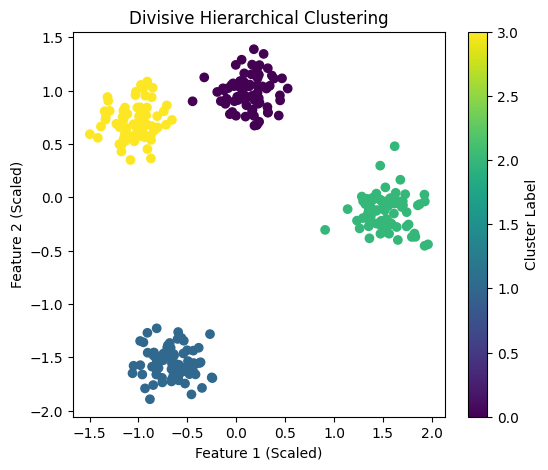

In [ ]:
# Use the divisive_clustering function and visualize the results
divisive_labels = divisive_clustering(X_scaled, n_clusters=4)

plt.figure(figsize=(6, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=divisive_labels, cmap='viridis')
plt.title("Divisive Hierarchical Clustering")
plt.xlabel("Feature 1 (Scaled)")
plt.ylabel("Feature 2 (Scaled)")
plt.colorbar(label='Cluster Label')
plt.show()

**Grivan-Newman algorithm**

Detected Communities:
Community 1: [0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21]
Community 2: [2, 8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]


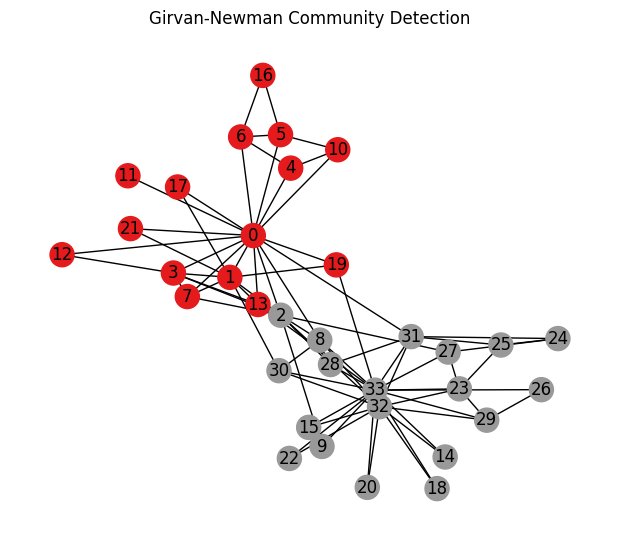

In [ ]:
#true divisive follows Grivan-Newman algorithm (mostly used for community detection)
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import girvan_newman
G = nx.karate_club_graph()   # Famous graph dataset
communities_generator = girvan_newman(G)
# Get first level split (2 communities)
first_level_communities = next(communities_generator)
# Convert to list
communities = [list(c) for c in first_level_communities]
print("Detected Communities:")
for i, community in enumerate(communities):
    print(f"Community {i+1}: {community}")
pos = nx.spring_layout(G, seed=42)
color_map = []
for node in G.nodes():
    for i, community in enumerate(communities):
        if node in community:
            color_map.append(i)
plt.figure(figsize=(6, 5))
nx.draw(G, pos, node_color=color_map, with_labels=True, cmap=plt.cm.Set1)
plt.title("Girvan-Newman Community Detection")
plt.show()